In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')


In [3]:
from sklearn.datasets import load_iris, fetch_california_housing
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor, plot_tree, export_text
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.metrics import r2_score, accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.preprocessing import LabelEncoder

np.random.seed(42)
print("Imports")

Imports


In [5]:
california = fetch_california_housing(as_frame=True)

X = california.data
y = california.target
df = california.frame

print(f'Shape : {df.shape}')
print(f'Target: Median House value')
print(f' Feature Descriptions')
for name, desc in zip(california.feature_names, california.DESCR.split('\n')[28:36]):
    print(f"  {name:<12}: {desc.strip()[:60]}")
df.head()

Shape : (20640, 9)
Target: Median House value
 Feature Descriptions
  MedInc      : 
  HouseAge    : This dataset was derived from the 1990 U.S. census, using on
  AveRooms    : block group. A block group is the smallest geographical unit
  AveBedrms   : Census Bureau publishes sample data (a block group typically
  Population  : of 600 to 3,000 people).
  AveOccup    : 
  Latitude    : A household is a group of people residing within a home. Sin
  Longitude   : number of rooms and bedrooms in this dataset are provided pe


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


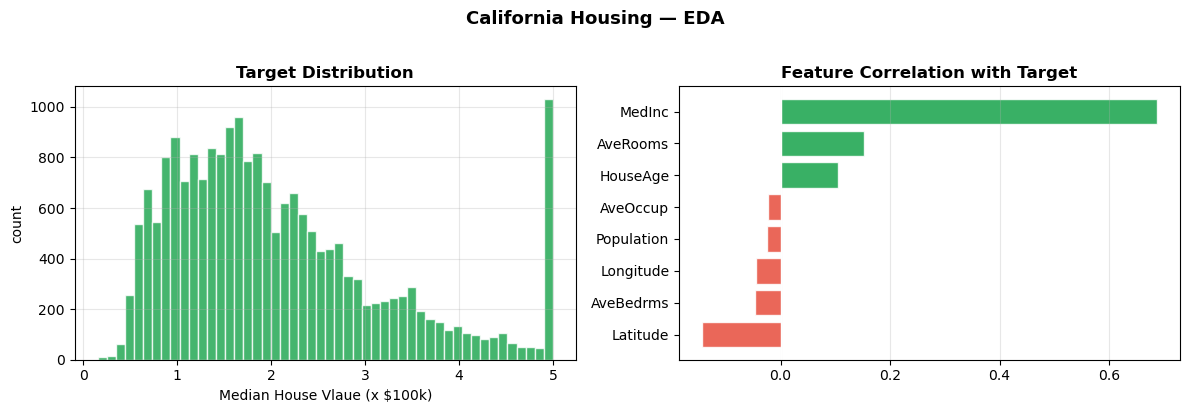

In [11]:
fig , axes = plt.subplots(1,2, figsize = (12,4))
axes[0].hist(y, bins =50, color = '#16a34a', alpha= 0.8 , edgecolor = 'white')
axes[0].set_xlabel(f'Median House Vlaue (x $100k)')
axes[0].set_ylabel('count')
axes[0].set_title('Target Distribution', fontweight ='bold')
axes[0].grid(True, alpha= 0.3)

corr = df.corr()['MedHouseVal'].drop('MedHouseVal').sort_values()
colors = ['#e74c3c' if v < 0 else '#16a34a' for v in corr]
bars = axes[1].barh(corr.index, corr.values, color=colors, alpha=0.85, edgecolor='white')
axes[1].set_title('Feature Correlation with Target', fontweight='bold')
axes[1].axvline(0, color='white', linewidth=0.8)
axes[1].grid(axis='x', alpha=0.3)

plt.suptitle('California Housing — EDA', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()
